# 04 – Discriminative Power of Features 

**Answers sub-question 1**: *Which trajectory-derived features most strongly distinguish normal from anomalous driving at a geometrically irregular junction, evaluated against rule-based behavioural categories drawn from the roundabout safety literature?*

## Method

For each feature `f` and each anomaly label `y` (the five rule columns plus `rule_any`):

1. **ROC-AUC** — area under the ROC curve treating `f` as a score and `y` as the binary target. 0.5 = no information; 1.0 = perfect separation. Robust to threshold choice and class imbalance.
2. **Mutual information** — non-parametric measure of dependence between `f` and `y` (using sklearn's k-NN estimator). Captures non-linear relationships that ROC-AUC may miss.
3. **Effect size** — standardised mean difference (Cohen's d) between the flagged and non-flagged distributions of `f`. Interpretable: |d| ≈ 0.2 small, 0.5 medium, 0.8 large.

All three should agree directionally, disagreement is a signal that the feature has a complicated relationship with the label (e.g. bimodal or non-monotonic).

#### Caveats kept in mind

1. The labels are themselves derived from features (`rule_hard_brake` ← `acceleration_ms2`, etc.). So it's expected for feature-X to look highly discriminative against its own rule. The interesting comparison is **cross-feature**: e.g. does `dist_nearest_m` predict `rule_hard_brake`, or does `yaw_rate_rads` predict `rule_path_deviation`?
2. NaN rows are excluded per-feature; the table reports how many rows each comparison was based on.
3. Imputation-contaminated rows (`accel_from_estimated`) are excluded for kinematic features and for `rule_hard_brake` (which already excludes them by definition).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif

## 1. Load labelled features

In [2]:
IN_PATH = Path('features_labelled.parquet') 

df = pd.read_parquet(IN_PATH)
# Cluster column comes back as numpy arrays in parquet; normalise to tuples for hashability.
if 'cluster' in df.columns:
    df['cluster'] = df['cluster'].apply(lambda c: tuple(c) if hasattr(c, '__iter__') else c)

print(f'Rows: {len(df):,}, vehicles: {df["ID"].nunique():,}')
print(f'\nRule firing rates:')
rule_cols = ['rule_hard_brake', 'rule_anomalous_stop', 'rule_path_deviation', 'rule_close_conflict', 'rule_any']
for r in rule_cols:
    print(f'  {r:25s}: {df[r].sum():5d} ({df[r].mean()*100:5.2f}%)')

Rows: 1,372,369, vehicles: 46,578

Rule firing rates:
  rule_hard_brake          : 21948 ( 1.60%)
  rule_anomalous_stop      :  2167 ( 0.16%)
  rule_path_deviation      :  6853 ( 0.50%)
  rule_close_conflict      :  1847 ( 0.13%)
  rule_any                 : 30852 ( 2.25%)


## 2. Define the feature set

Features are organised into groups so the resulting table is interpretable. Diagnostic columns (`Speed_ms_displ`, `accel_from_estimated`) are excluded, as are bookkeeping columns (`ID`, `Time`, `X`, `Y`, etc.). For features whose absolute value is meaningful (acceleration, heading change, yaw rate), what is also evaluated is the `abs()` version.

In [3]:
feature_groups = {
    'Kinematic': [
        'Speed_ms', 'acceleration_ms2', 'abs(acceleration_ms2)',
        'heading_change_rad', 'abs(heading_change_rad)',
        'yaw_rate_rads', 'abs(yaw_rate_rads)',
        'displacement_m',
    ],
    'Safety / interaction': [
        'dist_nearest_m',
    ],
    'Geometric': [
        'deviation_m', 'in_conflict_zone',
        'time_in_zone_running_s', 'time_in_zone_total_s',
    ],
    'Window (1s)': [
        'Speed_ms_mean_1s', 'Speed_ms_std_1s', 'Speed_ms_absmax_1s',
        'acceleration_ms2_mean_1s', 'acceleration_ms2_std_1s', 'acceleration_ms2_absmax_1s',
        'heading_change_rad_mean_1s', 'heading_change_rad_std_1s', 'heading_change_rad_absmax_1s',
    ],
    'Window (2s)': [
        'Speed_ms_mean_2s', 'Speed_ms_std_2s', 'Speed_ms_absmax_2s',
        'acceleration_ms2_mean_2s', 'acceleration_ms2_std_2s', 'acceleration_ms2_absmax_2s',
        'heading_change_rad_mean_2s', 'heading_change_rad_std_2s', 'heading_change_rad_absmax_2s',
    ],
}

# Materialise abs() versions as actual columns for downstream consistency.
for c in ['acceleration_ms2', 'heading_change_rad', 'yaw_rate_rads']:
    df[f'abs({c})'] = df[c].abs()

all_features = [f for group in feature_groups.values() for f in group]
print(f'Total features to evaluate: {len(all_features)}')

Total features to evaluate: 31


## 3. Compute discriminative metrics

In [4]:
def signed_auc(scores, labels):
    """AUC reported in [0, 1]; we always orient so AUC >= 0.5 (no information)."""
    if labels.sum() == 0 or labels.sum() == len(labels):
        return np.nan
    auc = roc_auc_score(labels, scores)
    return max(auc, 1 - auc)

def auc_direction(scores, labels):
    """Returns '+' if higher score → more likely flagged; '-' if lower score → more likely flagged."""
    if labels.sum() == 0 or labels.sum() == len(labels):
        return ' '
    return '+' if roc_auc_score(labels, scores) >= 0.5 else '-'

def cohens_d(scores, labels):
    a = scores[labels]
    b = scores[~labels]
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled_sd = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    if pooled_sd == 0:
        return np.nan
    return (a.mean() - b.mean()) / pooled_sd

def evaluate(df, feature, label, compute_mi=True):
    """Run the three metrics for one (feature, label) pair. Returns dict."""
    mask = df[feature].notna() & df[label].notna()
    if mask.sum() < 50:
        return {'n': int(mask.sum()), 'auc': np.nan, 'dir': ' ', 'mi': np.nan, 'd': np.nan}
    s = df.loc[mask, feature].to_numpy()
    y = df.loc[mask, label].to_numpy().astype(bool)
    if y.sum() < 2 or (~y).sum() < 2:
        return {'n': int(mask.sum()), 'auc': np.nan, 'dir': ' ', 'mi': np.nan, 'd': np.nan}
    auc = signed_auc(s, y)
    d = cohens_d(s, y)
    direction = auc_direction(s, y)
    if compute_mi:
        # Subsample to keep MI estimation fast (MI is the slowest of the three).
        n_sub = min(len(s), 20000)
        if len(s) > n_sub:
            idx = np.random.RandomState(0).choice(len(s), n_sub, replace=False)
            s_mi, y_mi = s[idx], y[idx]
        else:
            s_mi, y_mi = s, y
        try:
            mi = mutual_info_classif(s_mi.reshape(-1, 1), y_mi.astype(int), random_state=0)[0]
        except Exception:
            mi = np.nan
    else:
        mi = np.nan
    return {'n': int(mask.sum()), 'auc': auc, 'dir': direction, 'mi': mi, 'd': d}

labels_to_eval = ['rule_hard_brake', 'rule_anomalous_stop', 'rule_path_deviation', 'rule_close_conflict', 'rule_any']

import time
rows = []
t0 = time.time()
for group, feats in feature_groups.items():
    for feat in feats:
        if feat not in df.columns:
            continue
        # `in_conflict_zone` is a boolean — convert to int for these metrics.
        col = df[feat].astype(float) if df[feat].dtype == bool else df[feat]
        feat_df = df[[feat]].copy()
        feat_df[feat] = col
        for label in labels_to_eval:
            res = evaluate(df.assign(**{feat: col}), feat, label, compute_mi=True)
            rows.append({'group': group, 'feature': feat, 'label': label, **res})
    print(f'  [{time.time()-t0:5.1f}s] done {group}')

results = pd.DataFrame(rows)
print(f'\n{len(results)} (feature, label) pairs evaluated')

  [ 25.7s] done Kinematic
  [ 28.9s] done Safety / interaction
  [ 39.4s] done Geometric
  [ 67.5s] done Window (1s)
  [ 96.2s] done Window (2s)

155 (feature, label) pairs evaluated


## 4. Discriminative-power table, by label

For each anomaly label, features are ranked by AUC. Marked with `*` if the feature is the one used to construct the label (e.g. `acceleration_ms2` for `rule_hard_brake`) — those self-AUCs are expected to be near 1.0 and serve as a check, not a finding.

In [5]:
# Features that define each label, for marking.
label_defining_features = {
    'rule_hard_brake': {'acceleration_ms2', 'abs(acceleration_ms2)'},
    'rule_anomalous_stop': {'Speed_ms', 'in_conflict_zone', 'time_in_zone_running_s', 'time_in_zone_total_s'},
    'rule_path_deviation': {'deviation_m'},
    'rule_close_conflict': {'dist_nearest_m', 'acceleration_ms2', 'abs(acceleration_ms2)'},
    'rule_any': set(),  # too broad to mark
}

def fmt(x, digits=3):
    return f'{x:.{digits}f}' if pd.notna(x) else '   nan'

for label in labels_to_eval:
    sub = results[results['label'] == label].copy()
    sub = sub.sort_values('auc', ascending=False)
    print(f'\n========== Label: {label}  ({df[label].sum():,} positives / {len(df):,} rows) ==========')
    print(f'{"feature":40s} {"group":15s} {"AUC":>7s} {"dir":>4s} {"MI":>8s} {"Cohen d":>8s} {"n":>8s}')
    for _, r in sub.iterrows():
        marker = ' *' if r['feature'] in label_defining_features[label] else '  '
        print(f'{r["feature"]:40s} {r["group"]:15s} {fmt(r["auc"]):>7s} {r["dir"]:>4s} {fmt(r["mi"], 4):>8s} {fmt(r["d"]):>8s} {r["n"]:>8d}{marker}')


========== Label: rule_hard_brake  (21,948 positives / 1,372,369 rows) ==========
feature                                  group               AUC  dir       MI  Cohen d        n
Speed_ms_std_1s                          Window (1s)       0.912    +   0.0291    1.393  1291231  
acceleration_ms2_mean_1s                 Window (1s)       0.900    -   0.0323   -1.197  1289089  
acceleration_ms2                         Kinematic         0.897    -   0.0315   -1.131  1278163 *
Speed_ms_std_2s                          Window (2s)       0.863    +   0.0162    1.290  1296331  
acceleration_ms2_absmax_1s               Window (1s)       0.853    +   0.0250    0.859  1289089  
abs(acceleration_ms2)                    Kinematic         0.833    +   0.0196    0.752  1278163 *
acceleration_ms2_mean_2s                 Window (2s)       0.823    -   0.0169   -0.856  1293933  
acceleration_ms2_std_1s                  Window (1s)       0.778    +   0.0101    0.638  1289089  
acceleration_ms2_absmax_2s  

## 5. Cross-feature view – best non-self predictors per label

The most thesis-relevant table. For each label, the top-5 features *excluding those that define the label*. These are the features that genuinely add information — they discriminate the anomaly type using signals other than the one that built the rule. This is the substance of sub-question 1.

In [6]:
for label in labels_to_eval:
    sub = results[results['label'] == label].copy()
    defining = label_defining_features[label]
    sub_cross = sub[~sub['feature'].isin(defining)].sort_values('auc', ascending=False).head(5)
    print(f'\n--- {label} — top 5 non-self predictors ---')
    print(f'{"feature":40s} {"AUC":>7s} {"dir":>4s} {"Cohen d":>8s}')
    for _, r in sub_cross.iterrows():
        print(f'{r["feature"]:40s} {fmt(r["auc"]):>7s} {r["dir"]:>4s} {fmt(r["d"]):>8s}')


--- rule_hard_brake — top 5 non-self predictors ---
feature                                      AUC  dir  Cohen d
Speed_ms_std_1s                            0.912    +    1.393
acceleration_ms2_mean_1s                   0.900    -   -1.197
Speed_ms_std_2s                            0.863    +    1.290
acceleration_ms2_absmax_1s                 0.853    +    0.859
acceleration_ms2_mean_2s                   0.823    -   -0.856

--- rule_anomalous_stop — top 5 non-self predictors ---
feature                                      AUC  dir  Cohen d
Speed_ms_mean_1s                           0.985    -   -1.962
Speed_ms_absmax_1s                         0.984    -   -1.952
Speed_ms_mean_2s                           0.981    -   -1.949
Speed_ms_absmax_2s                         0.976    -   -1.896
displacement_m                             0.971    -   -1.253

--- rule_path_deviation — top 5 non-self predictors ---
feature                                      AUC  dir  Cohen d
heading_change

## 6. Heatmap: features × labels

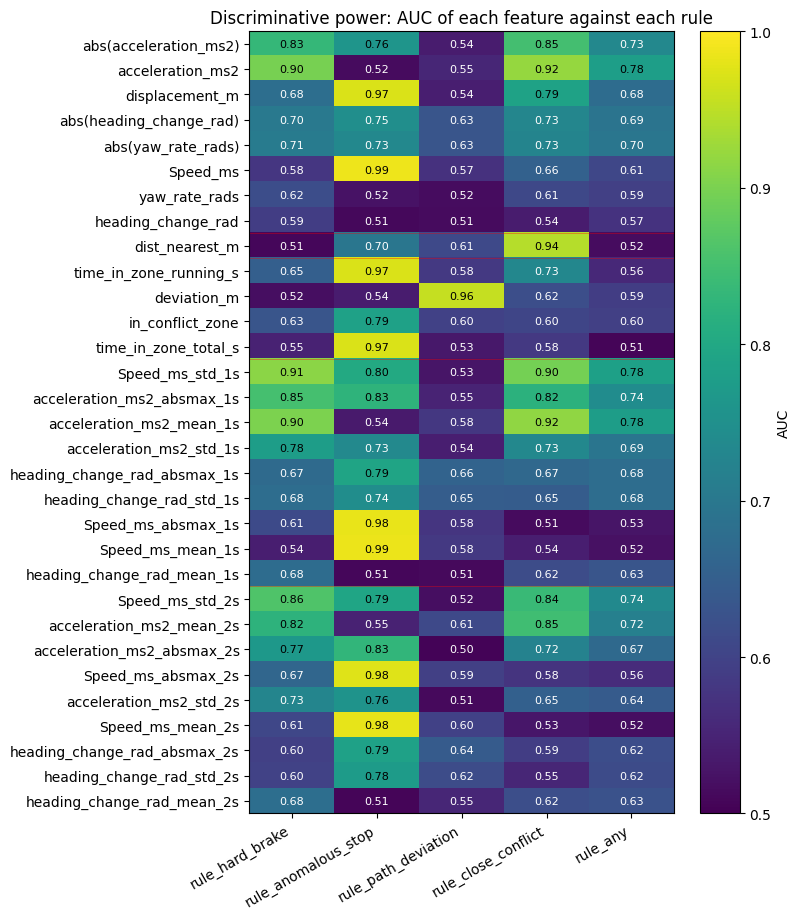

In [7]:
pivot = results.pivot(index='feature', columns='label', values='auc')
pivot = pivot[labels_to_eval]  # column order

# Re-order rows by group, then within group by overall mean AUC for readability.
feature_order = []
for group, feats in feature_groups.items():
    in_group = [f for f in feats if f in pivot.index]
    in_group.sort(key=lambda f: -pivot.loc[f].mean())
    feature_order.extend(in_group)
pivot = pivot.loc[feature_order]

fig, ax = plt.subplots(figsize=(8, max(6, 0.3 * len(pivot))))
im = ax.imshow(pivot.values, aspect='auto', cmap='viridis', vmin=0.5, vmax=1.0)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
plt.colorbar(im, ax=ax, label='AUC')

# Annotate each cell
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if pd.notna(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    color='white' if v < 0.75 else 'black', fontsize=8)

# Visually separate groups
y = -0.5
for group, feats in feature_groups.items():
    n = sum(1 for f in feats if f in pivot.index)
    if n == 0: continue
    y += n
    ax.axhline(y, color='red', linewidth=0.5, alpha=0.5)

ax.set_title('Discriminative power: AUC of each feature against each rule')
plt.tight_layout()
plt.savefig('discriminative_power_heatmap.png', dpi=130)
plt.show()

## 7. Save results table

In [8]:
results.to_csv('discriminative_power_table.csv', index=False)
print(f'Saved {len(results)} rows to discriminative_power_table.csv')
print(f'Saved heatmap to discriminative_power_heatmap.png')

Saved 155 rows to discriminative_power_table.csv
Saved heatmap to discriminative_power_heatmap.png
